In [1]:
!pip install python-docx joblib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.0 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


In [4]:
import os
import json
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from docx import Document
from datetime import datetime
import joblib

# CONFIGURATION

In [5]:
BASE_SAVE_DIR = "/users/"

DATASET_NAME = "CIC_IIoT_2025"
DATASET_DIR = os.path.join(BASE_SAVE_DIR, DATASET_NAME)

CLIENTS_DIR = os.path.join(DATASET_DIR, "clients_non_iid")
os.makedirs(CLIENTS_DIR, exist_ok=True)

N_CLIENTS = 10

DIRICHLET_ALPHA = 0.5

print("DATASET_DIR:", DATASET_DIR)
print("CLIENTS_DIR:", CLIENTS_DIR)
print("N_CLIENTS:", N_CLIENTS)
print("DIRICHLET_ALPHA:", DIRICHLET_ALPHA)

DATASET_DIR: /users/
CLIENTS_DIR: /users/
N_CLIENTS: 10
DIRICHLET_ALPHA: 0.5


# LOAD TRAIN LATENT FEATURES & LABELS


In [6]:
train_latent_path = os.path.join(DATASET_DIR, "train_latent.npy")
y_train_path      = os.path.join(DATASET_DIR, "y_train.npy")
label_encoder_path = os.path.join(DATASET_DIR, "label_encoder.pkl")

assert os.path.exists(train_latent_path), f"Missing: {train_latent_path}"
assert os.path.exists(y_train_path), f"Missing: {y_train_path}"
assert os.path.exists(label_encoder_path), f"Missing: {label_encoder_path}"

X_train = np.load(train_latent_path)
y_train = np.load(y_train_path)

label_encoder = joblib.load(label_encoder_path)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Loaded X_train shape:", X_train.shape)
print("Loaded y_train shape:", y_train.shape)
print("Number of classes:", num_classes)
print("Class names:", class_names)

Loaded X_train shape: (29424, 64)
Loaded y_train shape: (29424,)
Number of classes: 7
Class names: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


# GLOBAL CLASS DISTRIBUTION

Global class distribution (encoded):
Class 0 (0): 4204
Class 1 (1): 4204
Class 2 (2): 4203
Class 3 (3): 4203
Class 4 (4): 4203
Class 5 (5): 4204
Class 6 (6): 4203


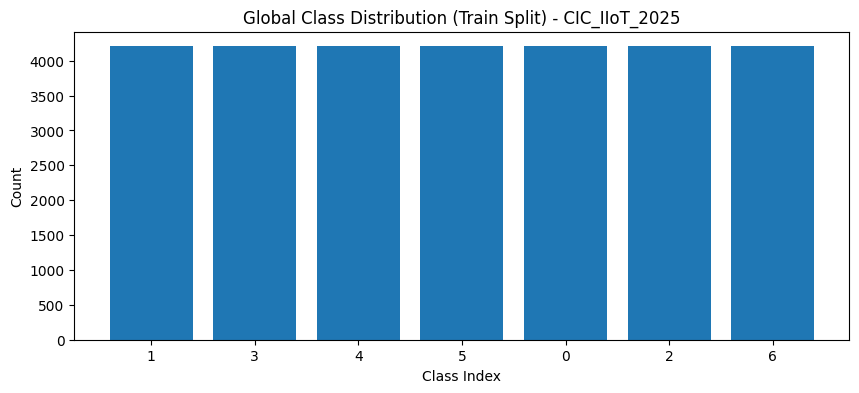

In [7]:
global_counts = Counter(y_train.tolist())
print("Global class distribution (encoded):")
for cls_idx, cnt in sorted(global_counts.items()):
    print(f"Class {cls_idx} ({class_names[cls_idx]}): {cnt}")

# Optional: quick bar plot
plt.figure(figsize=(10, 4))
plt.bar(
    [str(k) for k in global_counts.keys()],
    list(global_counts.values())
)
plt.title("Global Class Distribution (Train Split) - CIC_IIoT_2025")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

# DIRICHLET-BASED NON-IID PARTITIONING FUNCTION

In [8]:
def dirichlet_non_iid_partition(y, n_clients, alpha, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    n_classes = len(np.unique(y))
    all_indices = np.arange(len(y))

    # Indices of each class
    class_to_indices = {}
    for cls in range(n_classes):
        idx = all_indices[y == cls]
        np.random.shuffle(idx)
        class_to_indices[cls] = idx

    client_indices = [[] for _ in range(n_clients)]

    # For each class, sample Dirichlet proportions to allocate that class's samples across clients
    for cls, idxs in class_to_indices.items():
        n_samples = len(idxs)
        if n_samples == 0:
            continue

        # Sample proportions from Dirichlet
        proportions = np.random.dirichlet(alpha * np.ones(n_clients))

        # Convert proportions to counts per client (sum must equal n_samples)
        counts = (proportions * n_samples).astype(int)
        # Adjust due to rounding; assign remainder randomly
        diff = n_samples - np.sum(counts)
        for _ in range(diff):
            j = np.random.randint(0, n_clients)
            counts[j] += 1

        # Split indices accordingly
        start = 0
        for client_id in range(n_clients):
            c_count = counts[client_id]
            if c_count > 0:
                client_indices[client_id].extend(idxs[start:start + c_count])
                start += c_count

    # Convert each client's index list to numpy array and shuffle
    for client_id in range(n_clients):
        idx_array = np.array(client_indices[client_id])
        np.random.shuffle(idx_array)
        client_indices[client_id] = idx_array

    return client_indices

# BUILD NON-IID CLIENTS

In [9]:
client_indices = dirichlet_non_iid_partition(
    y_train,
    n_clients=N_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    seed=42
)

# Quick sanity checks
total_client_samples = sum(len(idx) for idx in client_indices)
print("Total samples across all clients:", total_client_samples)
print("Original train samples:", len(y_train))
assert total_client_samples == len(y_train), "Partitioning error: sample count mismatch!"

Total samples across all clients: 29424
Original train samples: 29424


# INSPECT SAMPLE DISTRIBUTION PER CLIENT

In [10]:
def get_class_distribution_for_indices(y, indices):
    subset_labels = y[indices]
    counts = Counter(subset_labels.tolist())
    return {int(k): int(v) for k, v in sorted(counts.items())}

client_stats = []

for cid, idxs in enumerate(client_indices):
    dist = get_class_distribution_for_indices(y_train, idxs)
    num_samples = len(idxs)
    num_classes_in_client = len(dist)
    top_classes = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:3]
    top_classes_str = [
        f"{cls_idx}({class_names[cls_idx]}):{cnt}" for cls_idx, cnt in top_classes
    ]
    client_stats.append({
        "client_id": cid,
        "num_samples": num_samples,
        "num_classes": num_classes_in_client,
        "class_distribution": dist,
        "top_classes": top_classes_str,
    })

# Print a nice summary
for s in client_stats:
    print(f"\nClient {s['client_id']}:")
    print("  Samples     :", s["num_samples"])
    print("  #Classes    :", s["num_classes"])
    print("  Top classes :", ", ".join(s["top_classes"]))


Client 0:
  Samples     : 2611
  #Classes    : 7
  Top classes : 0(0):1050, 6(6):681, 2(2):487

Client 1:
  Samples     : 5161
  #Classes    : 7
  Top classes : 1(1):1478, 4(4):1357, 6(6):926

Client 2:
  Samples     : 1834
  #Classes    : 6
  Top classes : 3(3):1061, 1(1):727, 0(0):27

Client 3:
  Samples     : 1787
  #Classes    : 7
  Top classes : 4(4):420, 0(0):405, 2(2):375

Client 4:
  Samples     : 3821
  #Classes    : 7
  Top classes : 2(2):1431, 5(5):946, 0(0):518

Client 5:
  Samples     : 3032
  #Classes    : 7
  Top classes : 0(0):1438, 3(3):750, 4(4):478

Client 6:
  Samples     : 2778
  #Classes    : 7
  Top classes : 5(5):1470, 4(4):797, 6(6):224

Client 7:
  Samples     : 745
  #Classes    : 7
  Top classes : 4(4):482, 0(0):102, 3(3):83

Client 8:
  Samples     : 3974
  #Classes    : 7
  Top classes : 3(3):1439, 1(1):761, 2(2):704

Client 9:
  Samples     : 3681
  #Classes    : 7
  Top classes : 6(6):1377, 1(1):658, 0(0):484


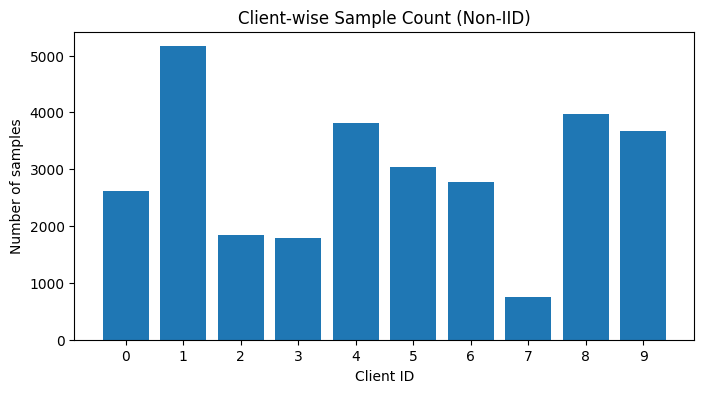

In [11]:
client_sizes = [s["num_samples"] for s in client_stats]

plt.figure(figsize=(8, 4))
plt.bar(range(N_CLIENTS), client_sizes)
plt.xlabel("Client ID")
plt.ylabel("Number of samples")
plt.title("Client-wise Sample Count (Non-IID)")
plt.xticks(range(N_CLIENTS))
plt.show()

# SAVE CLIENT DATASETS TO DISK

In [12]:
for cid, idxs in enumerate(client_indices):
    X_c = X_train[idxs]
    y_c = y_train[idxs]

    client_folder = os.path.join(CLIENTS_DIR, f"client_{cid}")
    os.makedirs(client_folder, exist_ok=True)

    np.save(os.path.join(client_folder, "X.npy"), X_c)
    np.save(os.path.join(client_folder, "y.npy"), y_c)

print("✔ Saved client-wise X/y .npy files to:", CLIENTS_DIR)

✔ Saved client-wise X/y .npy files to: /users/


# BUILD AND SAVE METADATA JSON

In [13]:
metadata = {
    "dataset_name": DATASET_NAME,
    "generated_at": datetime.now().isoformat(),
    "n_clients": N_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "global": {
        "num_samples": int(len(y_train)),
        "num_classes": int(num_classes),
        "class_index_to_name": {int(i): str(name) for i, name in enumerate(class_names)},
        "global_class_distribution": {int(k): int(v) for k, v in sorted(global_counts.items())},
    },
    "clients": []
}

for s in client_stats:
    cid = s["client_id"]
    metadata["clients"].append({
        "client_id": cid,
        "num_samples": int(s["num_samples"]),
        "num_classes": int(s["num_classes"]),
        "class_distribution": {int(k): int(v) for k, v in s["class_distribution"].items()},
        "top_classes_readable": s["top_classes"],
    })

meta_path = os.path.join(CLIENTS_DIR, "clients_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("✔ Saved metadata JSON to:", meta_path)

✔ Saved metadata JSON to: /users/


# GENERATE DOCX SUMMARY

In [14]:
doc = Document()
doc.add_heading(f"Client Partition Summary — {DATASET_NAME} (Non-IID)", level=1)

doc.add_paragraph(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
doc.add_paragraph(f"Number of clients: {N_CLIENTS}")
doc.add_paragraph(f"Dirichlet alpha (non-IID strength): {DIRICHLET_ALPHA}")
doc.add_paragraph(f"Total train samples: {len(y_train)}")
doc.add_paragraph(f"Number of classes: {num_classes}")

doc.add_heading("Global Class Distribution", level=2)
for cls_idx, cnt in sorted(global_counts.items()):
    doc.add_paragraph(
        f"Class {cls_idx} ({class_names[cls_idx]}): {cnt}",
        style="List Bullet"
    )

doc.add_heading("Client-wise Summary", level=2)

table = doc.add_table(rows=1, cols=5)
hdr_cells = table.rows[0].cells
hdr_cells[0].text = "Client ID"
hdr_cells[1].text = "#Samples"
hdr_cells[2].text = "#Classes"
hdr_cells[3].text = "Top Classes (idx:name:count)"
hdr_cells[4].text = "Total Class Dist (truncated)"

for s in client_stats:
    row_cells = table.add_row().cells
    row_cells[0].text = str(s["client_id"])
    row_cells[1].text = str(s["num_samples"])
    row_cells[2].text = str(s["num_classes"])
    row_cells[3].text = ", ".join(s["top_classes"])

    # Truncate full dist for readability
    dist_items = list(s["class_distribution"].items())
    dist_str = ", ".join(
        f"{cls}({class_names[cls]}):{cnt}" for cls, cnt in dist_items[:5]
    )
    if len(dist_items) > 5:
        dist_str += " ..."
    row_cells[4].text = dist_str

docx_path = os.path.join(CLIENTS_DIR, "clients_metadata_summary.docx")
doc.save(docx_path)

print("✔ DOCX summary saved to:", docx_path)

✔ DOCX summary saved to: /users/
